#EXPLORATORY DATA ANALYSIS ON A DATASET

# 	Data Cleaning and Preparation:

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#LOADING THE DATASET
df = pd.read_csv('Cardiotocographic.csv')

In [ ]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


1. In here info() describes all the values are in float type
2. In this dataset, all cardiographic variables should be numeric because they represent measurements


In [ ]:
df.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)


/tmp/ipython-input-2525240287.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


In [ ]:
df.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [ ]:
# Identify columns stored as object (string)
object_cols = df.select_dtypes(include='object').columns
object_cols


Index([], dtype='object')

In [ ]:
#identification of outliner
num_cols = df.select_dtypes(include=np.number).columns
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = outliers.shape[0]

outlier_summary



{'LB': 10,
 'AC': 43,
 'FM': 347,
 'UC': 13,
 'DL': 125,
 'DS': 120,
 'DP': 284,
 'ASTV': 10,
 'MSTV': 80,
 'ALTV': 318,
 'MLTV': 81,
 'Width': 10,
 'Tendency': 10,
 'NSP': 559}

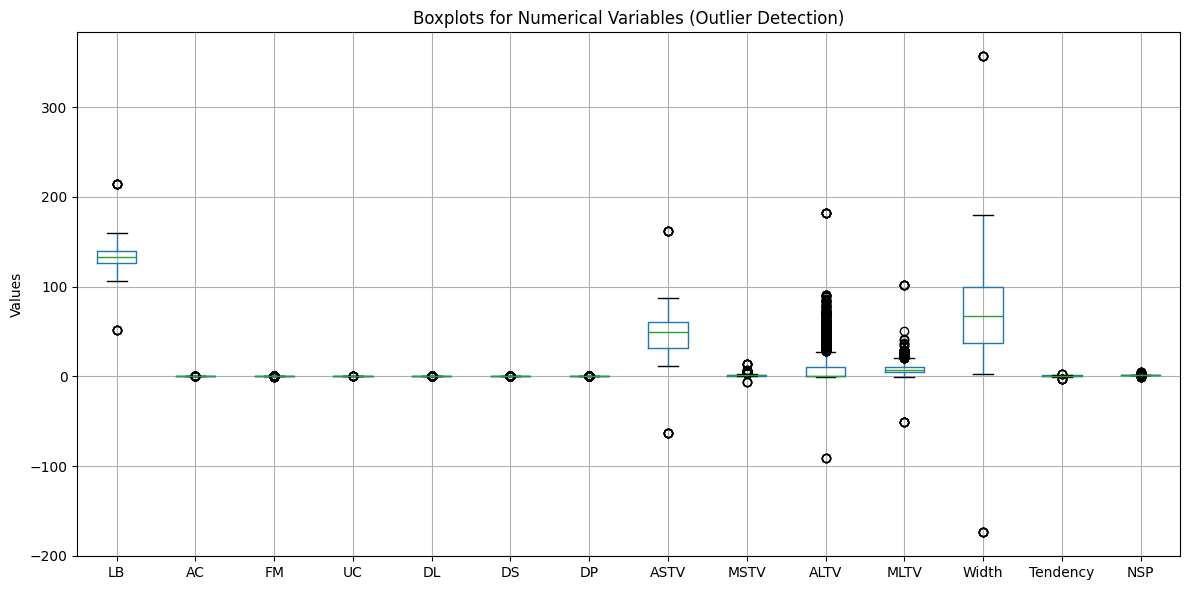

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df[num_cols].boxplot(rot=360)
plt.title("Boxplots for Numerical Variables (Outlier Detection)")
plt.ylabel("Values")
plt.tight_layout()
plt.show()


In [ ]:
df_winsorized = df.copy()

for col in num_cols:
    lower = df_winsorized[col].quantile(0.01)
    upper = df_winsorized[col].quantile(0.99)
    df_winsorized[col] = np.clip(df_winsorized[col], lower, upper)


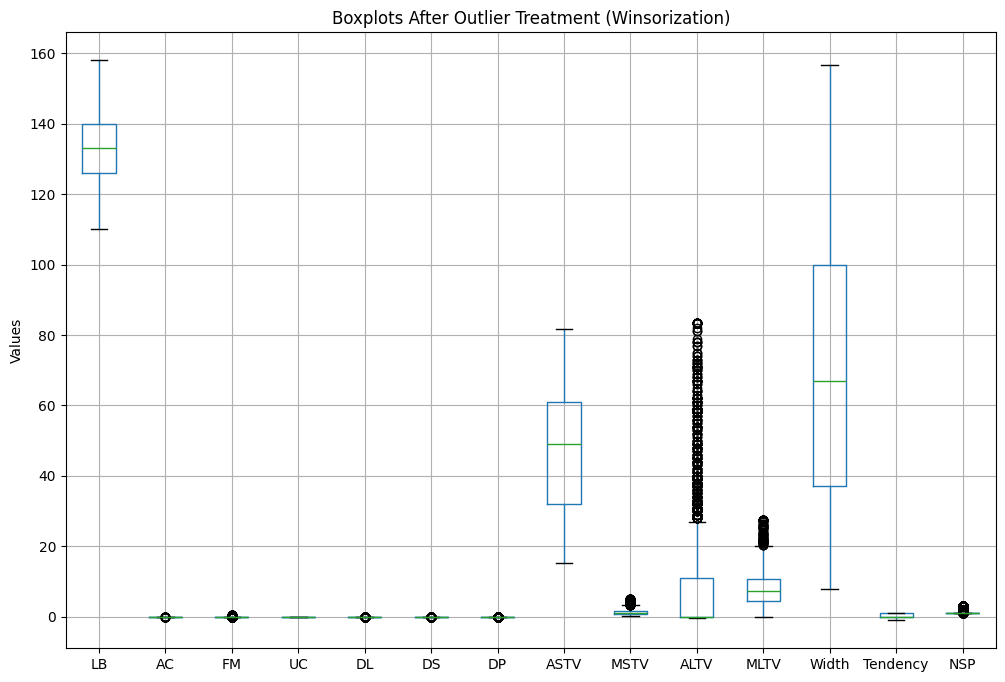

In [ ]:
plt.figure(figsize=(12, 8))
df_winsorized[num_cols].boxplot(rot=0)
plt.title("Boxplots After Outlier Treatment (Winsorization)")
plt.ylabel("Values")
plt.show()


Outliers were identified using the Interquartile Range (IQR) method and visualized using boxplots. Instead of removing outliers, Winsorization was applied to cap extreme values at the 1st and 99th percentiles. This approach preserves clinically relevant information while reducing the influence of extreme values on statistical analysis and modeling.

#Statistical Summary

In [ ]:
df.statistical_summary=df.describe()
df.statistical_summary

/tmp/ipython-input-1929749148.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.statistical_summary=df.describe()


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000




1.   LB
      
      The mean and median values of LB are close, indicating a near-symmetrical distribution

2.   AC

      The median is lower than the mean, indicating a right-skewed distribution

3.   FM
  
      Both values  mean and median are low, with the median often close to zero.

4.  UC

     Median is lower than the mean, indicating skewness.

5.  DL

     Median is or near zero.     

6. DS

     Mean slightly higher than median.     

# summary

1. Baseline Fetal Heart Rate (LB)

     Mean ≈ Median, indicating a fairly symmetrical distribution.

2. Accelerations (AC)

    Median is much lower than the mean, showing a right-skewed distribution.

3. Fetal Movements (FM)

    Highly skewed distribution with a median of 0.

4. Uterine Contractions (UC)

  Low average values with limited variability.

5. Decelerations (DL, DS, DP)

   DL (Late Decelerations): Mostly zeros → rare but clinically important when present.

   DS (Short Decelerations): Slightly more frequent than DL.

   DP (Prolonged Decelerations): Very rare with extreme outliers.

6. Short-Term Variability (ASTV, MSTV)

   ASTV: High mean with wide spread → many observations show abnormal short-term variability.

   MSTV: Lower dispersion and more stable distribution.

7. Long-Term Variability (ALTV, MLTV)

   ALTV: Highly skewed with many zeros and some large values.

   MLTV: More normally distributed with moderate variance.

**Overall Distribution Patterns**

  Many variables show right-skewness and excess zeros.

#	Data Visualization

histograms

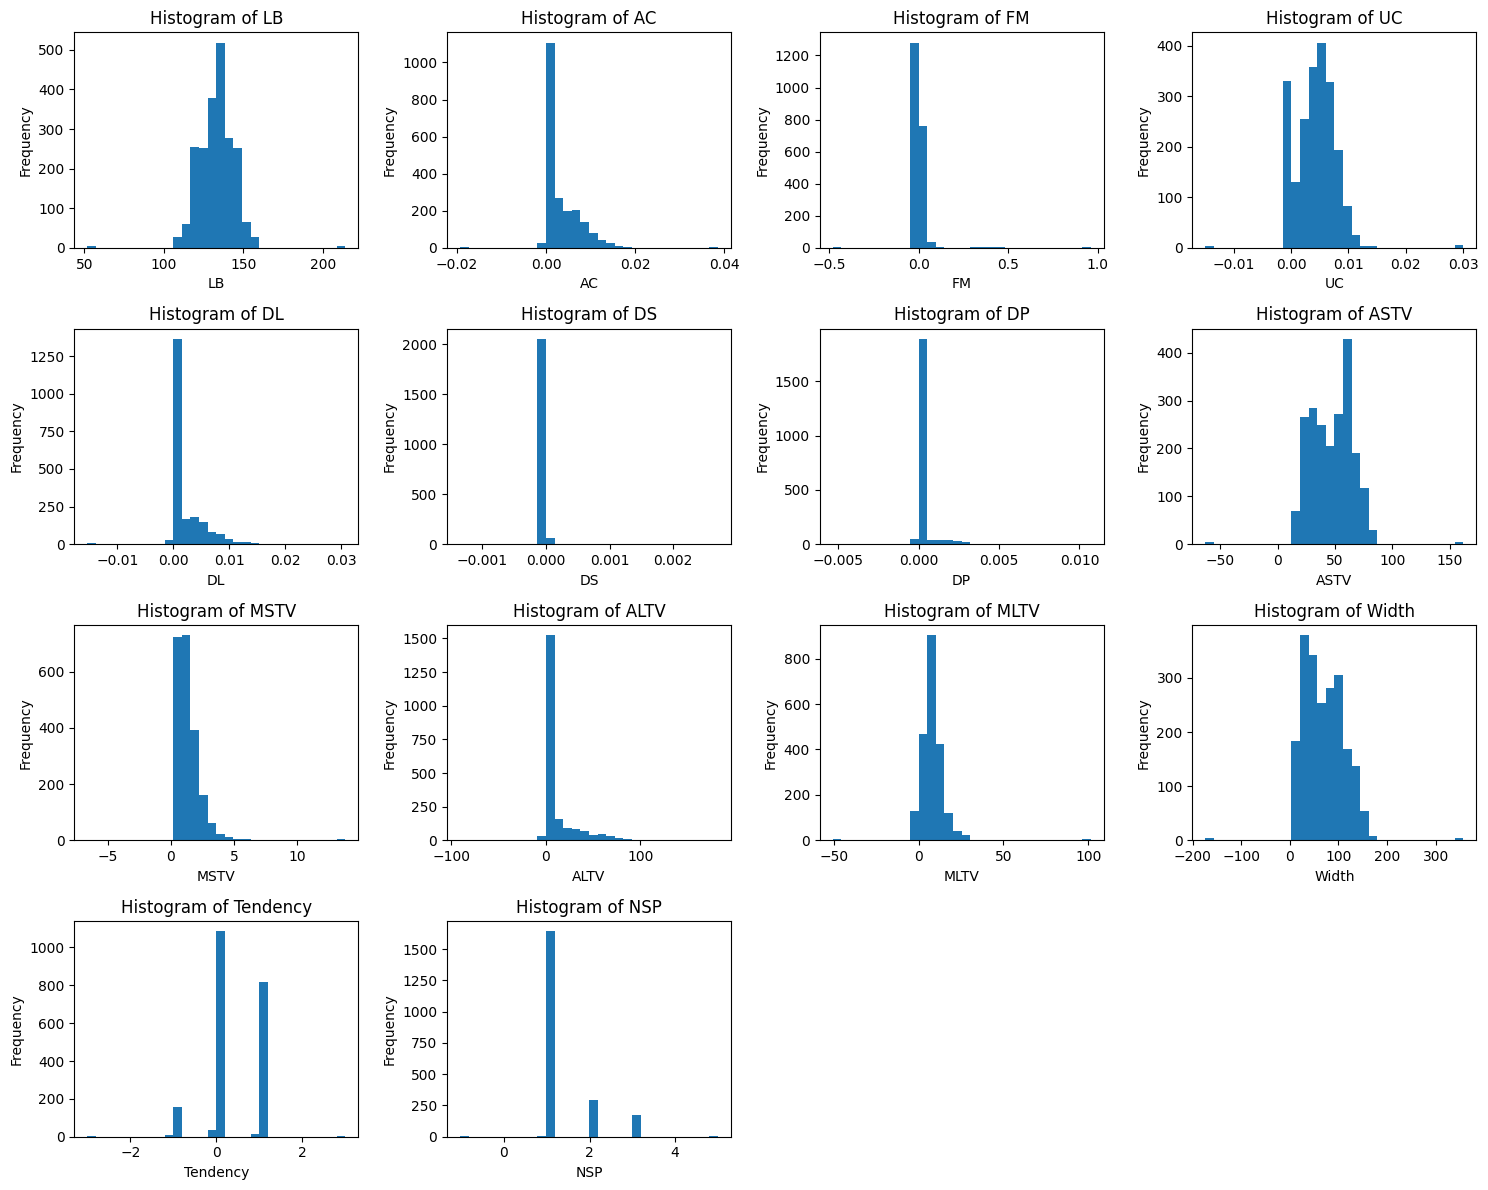

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    plt.hist(df[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


#Pie chart

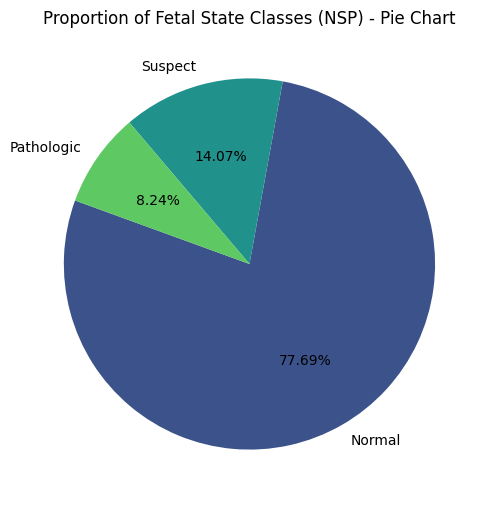

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

nsp_counts = df['NSP'].value_counts()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 2)
plt.pie(nsp_counts.reindex([1.0, 2.0, 3.0]),
        labels=['Normal', 'Suspect', 'Pathologic'],
        autopct='%1.2f%%',
        colors=sns.color_palette('viridis', 3),
        startangle=160)
plt.title('Proportion of Fetal State Classes (NSP) - Pie Chart')

plt.tight_layout()
plt.show()

#heatmap

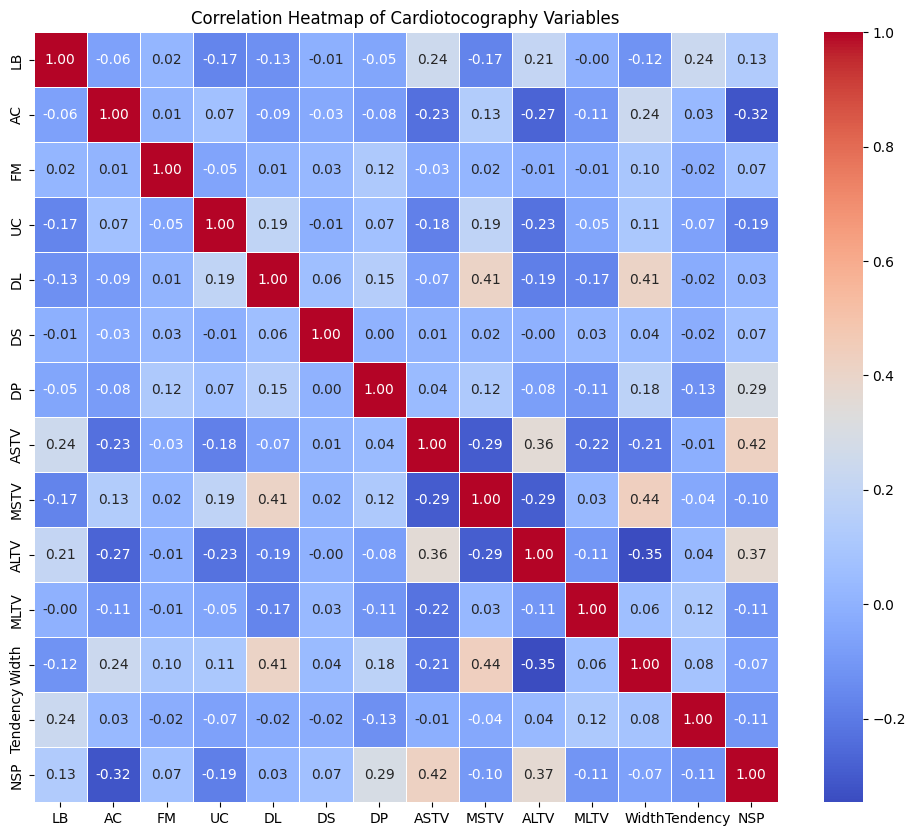

In [ ]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Cardiotocography Variables')
plt.show()

/tmp/ipython-input-149081148.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NSP_Label', y='LB', data=df_winsorized, ax=axes[0], palette="muted", order=['Normal', 'Suspect', 'Pathologic'])
/tmp/ipython-input-149081148.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NSP_Label', y='ASTV', data=df_winsorized, ax=axes[1], palette="muted", order=['Normal', 'Suspect', 'Pathologic'])
/tmp/ipython-input-149081148.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NSP_Label', y='MSTV', data=df_winsorized, ax=axes[2], pal

Violin plots and Pair plots created successfully.


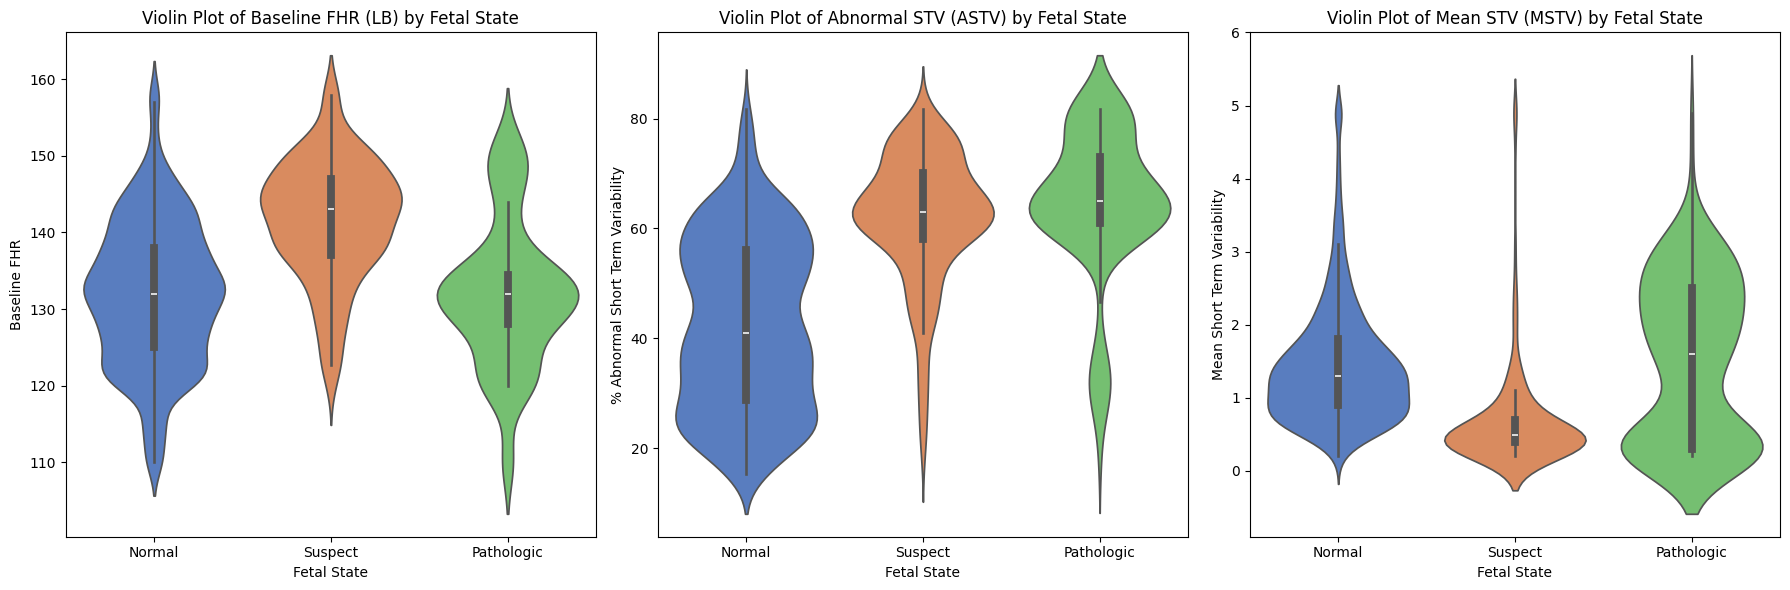

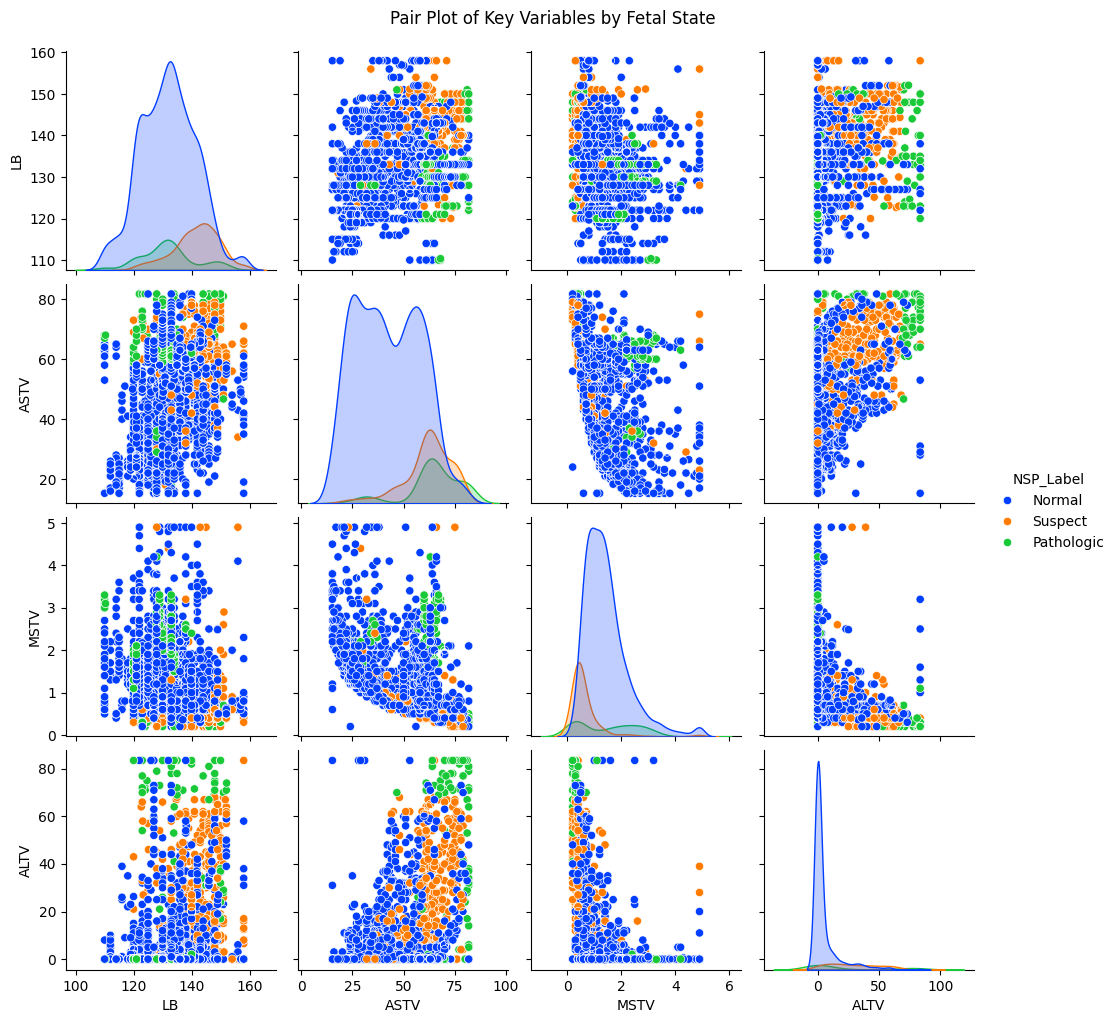

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def get_nsp_label(nsp_value):
    if nsp_value == 1.0:
        return 'Normal'
    elif nsp_value == 2.0:
        return 'Suspect'
    elif nsp_value == 3.0:
        return 'Pathologic'
    else:
        return 'Other'

df_winsorized['NSP_Label'] = df_winsorized['NSP'].apply(get_nsp_label)

sns.violinplot(x='NSP_Label', y='LB', data=df_winsorized, ax=axes[0], palette="muted", order=['Normal', 'Suspect', 'Pathologic'])
axes[0].set_title('Violin Plot of Baseline FHR (LB) by Fetal State')
axes[0].set_xlabel('Fetal State')
axes[0].set_ylabel('Baseline FHR')

sns.violinplot(x='NSP_Label', y='ASTV', data=df_winsorized, ax=axes[1], palette="muted", order=['Normal', 'Suspect', 'Pathologic'])
axes[1].set_title('Violin Plot of Abnormal STV (ASTV) by Fetal State')
axes[1].set_xlabel('Fetal State')
axes[1].set_ylabel('% Abnormal Short Term Variability')

sns.violinplot(x='NSP_Label', y='MSTV', data=df_winsorized, ax=axes[2], palette="muted", order=['Normal', 'Suspect', 'Pathologic'])
axes[2].set_title('Violin Plot of Mean STV (MSTV) by Fetal State')
axes[2].set_xlabel('Fetal State')
axes[2].set_ylabel('Mean Short Term Variability')

plt.tight_layout()
plt.savefig('violin_plots.png')


pair_plot_vars = ['LB', 'ASTV', 'MSTV', 'ALTV', 'NSP_Label']
pair_plot = sns.pairplot(df_winsorized[pair_plot_vars], hue='NSP_Label', palette="bright", hue_order=['Normal', 'Suspect', 'Pathologic'])
pair_plot.fig.suptitle('Pair Plot of Key Variables by Fetal State', y=1.02)
pair_plot.savefig('pair_plot.png')

print("Violin plots and Pair plots created successfully.")

#Pattern Recognition and Insights



1.  Pattern Recognition and Correlation Implications
  The correlation heatmap highlights relationships, particularly those involving the target variable, NSP
2.  **Correlations with Fetal State (NSP)** - The Most Critical Finding
The NSP variable is the classification outcome, so its correlations are the most important for predicting fetal health
3. **Inter-Feature Correlations (Clinical Consistency)**
Strong correlations among the predictor variables confirm expected clinical relationships



#Looking for trends or patterns

**Limitation:** The provided dataset  consists of aggregated summary statistics for each fetal monitoring session. It does not contain any explicit temporal column such as a date, time stamp, or sequence number indicating the order of readings over time.

**Conclusion:** It is not possible to identify trends or patterns over time  with this specific dataset structure. The analysis is limited to finding static relationships between the summary measures, as detailed by the correlation

#CONCLUSION

1. **Indicators of Fetal Distress**
The analysis confirms that the primary indicators of fetal distress are related to decelerations and reduced variability.

DL is the Strongest Predictor: DL shows the highest positive correlation  with the Fetal State Class Code . The distribution plots show that Pathologic records have the highest rate of Late Decelerations, while Normal records have virtually none.

ASTV: The percentage of time with Abnormal Short Term Variability is a highly significant predictor, with a strong positive correlation  with NSP.



2. **Indicators of Fetal Well-being**
Accelerations  is the Best Indicator: The presence of Accelerations  shows the strongest negative correlation  with NSP. High AC is strongly associated with a Normal state, while Pathologic records show virtually zero accelerations.

MSTV: High MSTV is also strongly associated with a Normal state . Pathologic records show a distinct decrease in the median MSTV compared to Normal records.

3. **Data Distribution and Structure**
Extreme Skewness: Clinically rare events  exhibit extreme positive skewness, with the majority of records showing a value of zero. This highlights the importance of the non-zero rate for these variables in the minority of cases where pathology is present.

Dataset Dominance: The dataset is heavily dominated by Normal cases, as indicated by the median NSP of 1.00.

Impact on Decision-Making and Further Analyses
The findings from this exploratory analysis have significant implications for clinical decision-making and subsequent modeling efforts:

A.  **Feature Engineering and Model Selection
Focus on Key Predictors:**
      Machine learning models for classifying fetal state should primarily focus on DL, ASTV, AC, and MSTV. The high correlation of these variables suggests they carry the most discriminatory power.

Handling Skewed Data: Variables with extreme zero-inflation require specialized handling. Further analysis should explore:

Binary features: Creating a binary flag

Non-linear models: Given the non-linear relationship , non-linear classification algorithms  are likely to perform better than linear models.

Outlier Treatment for Clinical Sense: The initial data cleaning of nonsensical negative values was crucial. In a clinical setting, this would highlight the need for strict data validation at the point of collection.

B.** Clinical Interpretation**
Deceleration Priority: The analysis statistically validates the clinical priority given to Late Decelerations  as the most critical sign of fetal distress. Any observation with non-zero DL should be immediately flagged.

Variability as a Health Metric: The clear separation in the distributions of ASTV  and MSTV  across the NSP classes confirms that variability measures are essential indicators of fetal oxygenation status.

Decision Rule Formulation: The data suggests simple, high-impact decision rules could be formulated:

IF AC > Threshold → Likely Normal.

IF DL > 0 OR ASTV > Threshold → Likely Pathologic.

C. **Addressing Imbalance**
The dominance of Normal cases (NSP=1) requires careful attention in the modeling phase:

Resampling Techniques: Techniques like SMOTE  or other forms of oversampling/undersampling will be necessary to prevent the model from becoming biased toward the majority class and failing to accurately predict the critical Suspect  and Pathologic  outcomes.

Evaluation Metrics : Future model evaluation should rely on metrics appropriate for imbalanced data, such as Precision, Recall, F1-Score, and the Area Under the ROC Curve , rather than simple accuracy.